### Import Libraries

In [269]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load Dataset

In [270]:
Heart_CSV = pd.read_csv("disease_prediction.csv")
Heart_CSV.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [271]:
Heart_CSV.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   str    
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   str    
 10  alcohol_consumption  1000 non-null   str    
 11  physical_activity    1000 non-null   str    
 12  family_history       1000 non-null   str    
 13  disease              1000 non-null   str    
dtypes: float64(1), int64(7), str(6)
memory usage: 109.5 KB


### Visualize BMI distribution by disease

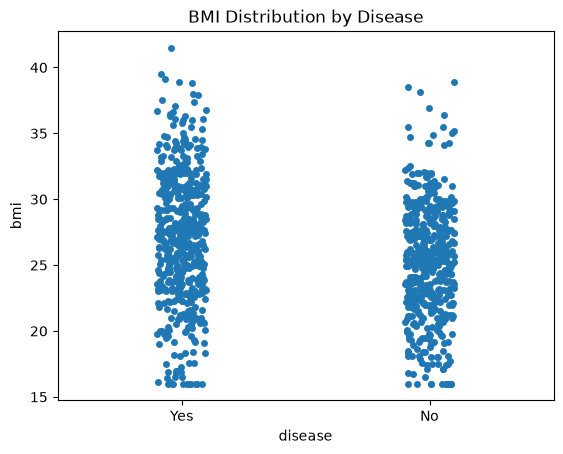

In [272]:
sns.stripplot(
    x='disease',
    y='bmi',
    data=Heart_CSV,
    jitter=True
)
plt.title("BMI Distribution by Disease")
plt.show()

### Encode categorical variables

In [273]:
Heart_CSV = pd.get_dummies(
    Heart_CSV,
    columns=[
        'gender',
        'smoking',
        'alcohol_consumption',
        'physical_activity',
        'family_history',
        'disease'
    ],
    drop_first=True,
    dtype=int
)
Heart_CSV.head()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,gender_Male,smoking_Yes,alcohol_consumption_Yes,physical_activity_Low,physical_activity_Medium,family_history_Yes,disease_Yes
0,1,32,101,235,152,79,28.5,73,1,0,1,1,0,1,1
1,2,31,124,191,134,77,33.9,71,1,0,1,1,0,1,1
2,3,45,57,141,114,71,27.2,79,1,1,1,1,0,0,0
3,4,75,69,268,120,82,21.5,61,0,1,1,0,1,0,1
4,5,53,107,163,131,75,23.3,73,1,1,0,1,0,1,1


### Select Features (X) and Target (y)
### Exclude patient_id because it is only an identifier
### Exclude disease because it is the target variable

In [274]:
X = Heart_CSV.drop(columns=['patient_id', 'disease_Yes'])
y = Heart_CSV['disease_Yes']

### Split the dataset

In [275]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Standardize Features
# KNN is distance-based, so feature scaling is required

In [276]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [277]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train the K-Nearest Neighbors (KNN) model

In [278]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

### Make Predictions

In [279]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Evaluate the Model

In [280]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8
[[87 18]
 [22 73]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       105
           1       0.80      0.77      0.78        95

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



-----

### FInding Best value of K by Elbow method

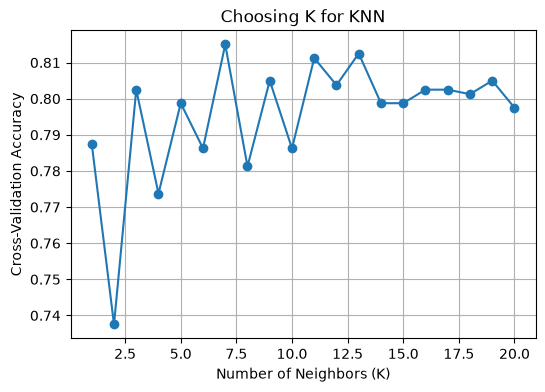

Best K: 7


In [284]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Store cross-validation accuracy for each K
accuracy = []

# Test K values from 1 to 20
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    
    # Perform 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Store the average accuracy
    accuracy.append(scores.mean())

# Plot Accuracy vs K
plt.figure(figsize=(6,4))
plt.plot(range(1, 21), accuracy, marker='o')
plt.title("Choosing K for KNN")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validation Accuracy")
plt.grid(True)
plt.show()

# Best K
best_k = accuracy.index(max(accuracy)) + 1
print("Best K:", best_k)